
[1/7] Aligning all factor rasters to the reference raster...
Saved aligned AOI rasters to: /Users/rubenmueller/Desktop/landslide_susceptibility_workflow/results/01_aligned_aoi

[2/7] Masking aligned rasters by the viewshed...
Saved viewshed-masked rasters to: /Users/rubenmueller/Desktop/landslide_susceptibility_workflow/results/02_viewshed_masked

[3/7] Computing class statistics, FR, WI and WF from TRAINING data (80%)...
Saved class lookup table to: /Users/rubenmueller/Desktop/landslide_susceptibility_workflow/results/03_lookup_tables/class_lookup_FR_WI_train80.csv
Saved factor lookup table to: /Users/rubenmueller/Desktop/landslide_susceptibility_workflow/results/03_lookup_tables/factor_lookup_WF_train80.csv

[4/7] Creating FR and weighted factor rasters for the full AOI...
Saved final LSI map to: /Users/rubenmueller/Desktop/landslide_susceptibility_workflow/results/06_final_maps/LSI_final_train80_AOI.tif
Saved final weighted map to: /Users/rubenmueller/Desktop/landslide_susceptibili

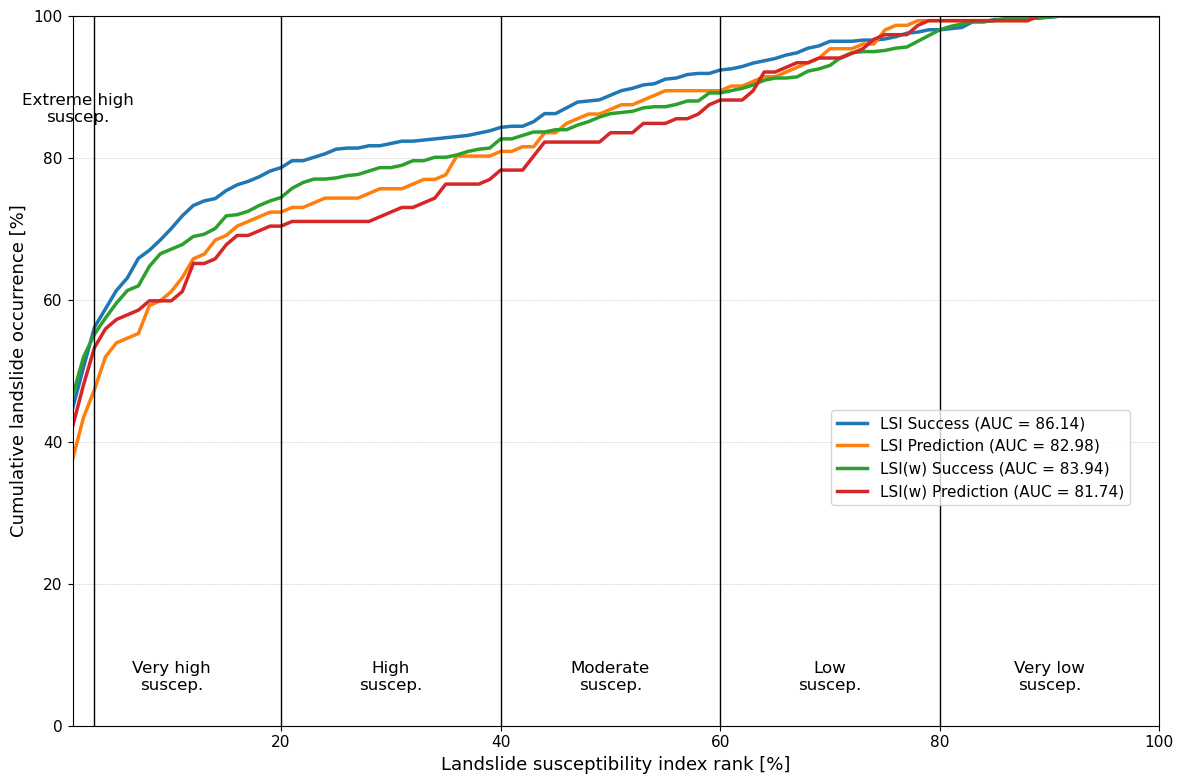

Saved validation plot to: /Users/rubenmueller/Desktop/landslide_susceptibility_workflow/results/07_validation/success_prediction_plot_train80.png

Workflow finished successfully.


In [ ]:
# ============================================================
# LANDSLIDE SUSCEPTIBILITY WORKFLOW
# ============================================================
#
# BENÖTIGTE EINGANGSDATEN
# -----------------------
# 1. Ordner mit allen Faktor-Rastern (GeoTIFF), bereits klassifiziert
# 2. Viewshed-Shapefile
# 3. 80%-Shapefile der Landslides (Training / Modellbildung / Success Rate)
# 4. 20%-Shapefile der Landslides (Test / Prediction Rate)
#
# OUTPUTS
# -------
# - aligned Faktor-Raster (AOI)
# - viewshed-maskierte Faktor-Raster
# - class_lookup_FR_WI_train80.csv
# - factor_lookup_WF_train80.csv
# - FR-Faktorraster
# - weighted Faktorraster (WI * WF)
# - finale Karten:
#     * LSI_final_train80_AOI.tif
#     * LSI_weighted_final_train80_AOI.tif
# - klassifizierte finale Karten:
#     * LSI_final_train80_AOI_classified.tif
#     * LSI_weighted_final_train80_AOI_classified.tif
# - Klassenschwellen:
#     * final_map_percentiles_train80.csv
# - Validierung:
#     * success_prediction_validation_train80.csv
#     * success_prediction_plot_train80.png
#
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling
from sklearn.metrics import auc
import matplotlib.pyplot as plt


# ============================================================
# 1. KONFIGURATION (PORTABLE VERSION)
# ============================================================

BASE_DIR = Path("xxx/landslide_susceptibility_workflow") ### hier den richtigen Pfad einfügen

# ------------------------------------------------------------
# INPUT DATEN
# ------------------------------------------------------------
INPUT_RASTER_DIR = BASE_DIR / "data_example" / "factors"
TRAIN_80_SHP = BASE_DIR / "data_example" / "train" / "train_points.shp"
TEST_20_SHP = BASE_DIR / "data_example" / "test" / "test_points.shp"
VIEWSHED_SHP = BASE_DIR / "data_example" / "viewshed" / "viewshed_1.shp"

# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------
OUTPUT_DIR = BASE_DIR / "results"

ALIGNED_AOI_DIR = OUTPUT_DIR / "01_aligned_aoi"
VIEWSHED_MASKED_DIR = OUTPUT_DIR / "02_viewshed_masked"
LOOKUP_DIR = OUTPUT_DIR / "03_lookup_tables"
FR_FACTOR_DIR = OUTPUT_DIR / "04_fr_factor_rasters"
WEIGHTED_FACTOR_DIR = OUTPUT_DIR / "05_weighted_factor_rasters"
FINAL_MAP_DIR = OUTPUT_DIR / "06_final_maps"
VALIDATION_DIR = OUTPUT_DIR / "07_validation"

for p in [
    OUTPUT_DIR,
    ALIGNED_AOI_DIR,
    VIEWSHED_MASKED_DIR,
    LOOKUP_DIR,
    FR_FACTOR_DIR,
    WEIGHTED_FACTOR_DIR,
    FINAL_MAP_DIR,
    VALIDATION_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# REFERENZRASTER
# ------------------------------------------------------------
REFERENCE_RASTER_NAME = None
REFERENCE_RASTER_KEYWORD = "dgm"

# ------------------------------------------------------------
# CRS FALLBACK
# ------------------------------------------------------------
DEFAULT_VECTOR_CRS = "EPSG:32648"

# ------------------------------------------------------------
# KLASSEN-GRENZEN
# ------------------------------------------------------------
PERCENTILE_BREAKS = [3, 20, 40, 60, 80]


# ============================================================
# 2. HILFSFUNKTIONEN
# ============================================================

def ensure_crs(gdf: gpd.GeoDataFrame, target_crs, default_crs: str) -> gpd.GeoDataFrame:
    """Setzt bei Bedarf ein Standard-CRS und projiziert auf target_crs um."""
    if gdf.crs is None:
        gdf = gdf.set_crs(default_crs)
    if gdf.crs != target_crs:
        gdf = gdf.to_crs(target_crs)
    return gdf


def get_reference_raster(raster_files):
    """Bestimmt das Referenzraster zum Alignen."""
    if REFERENCE_RASTER_NAME is not None:
        ref = [p for p in raster_files if p.name == REFERENCE_RASTER_NAME]
        if not ref:
            raise FileNotFoundError(f"Referenzraster '{REFERENCE_RASTER_NAME}' nicht gefunden.")
        return ref[0]

    ref = [p for p in raster_files if REFERENCE_RASTER_KEYWORD.lower() in p.stem.lower()]
    if not ref:
        raise FileNotFoundError(
            f"Kein Referenzraster gefunden. Bitte REFERENCE_RASTER_NAME setzen oder Keyword '{REFERENCE_RASTER_KEYWORD}' prüfen."
        )
    return ref[0]


def build_valid_mask(arr: np.ndarray, nodata):
    """Erzeugt gültige Pixelmaske, ohne Klassenwert 0 fälschlich auszuschließen."""
    mask = ~np.isnan(arr)
    if nodata is not None:
        mask &= (arr != nodata)
    return mask


def sample_raster_values(points_gdf: gpd.GeoDataFrame, raster_array: np.ndarray, transform, nodata=None):
    """Extrahiert Rasterwerte an Punktpositionen."""
    values = []
    for geom in points_gdf.geometry:
        if geom is None or geom.is_empty:
            continue

        x, y = geom.x, geom.y
        col, row = ~transform * (x, y)
        row, col = int(row), int(col)

        if 0 <= row < raster_array.shape[0] and 0 <= col < raster_array.shape[1]:
            val = raster_array[row, col]

            if nodata is not None and val == nodata:
                continue
            if np.isnan(val):
                continue

            values.append(val)

    return np.array(values)


def save_raster(array: np.ndarray, out_path: Path, meta_template: dict, nodata_value):
    """Speichert ein 2D-Array als GeoTIFF."""
    meta = meta_template.copy()
    meta.update(
        driver="GTiff",
        dtype="float32",
        count=1,
        nodata=nodata_value,
        height=array.shape[0],
        width=array.shape[1],
    )
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(array.astype(np.float32), 1)


def classify_percentile_map(arr: np.ndarray, nodata, percentile_breaks):
    """
    Klassifiziert finale Suszeptibilitätskarte nach Ranking:
    0-3%, 3-20%, 20-40%, 40-60%, 60-80%, 80-100%

    Klassen:
    6 = Extreme high
    5 = Very high
    4 = High
    3 = Moderate
    2 = Low
    1 = Very low
    """
    valid_mask = build_valid_mask(arr, nodata)
    values = arr[valid_mask]

    if len(values) == 0:
        raise ValueError("Keine gültigen Werte für die Klassifikation gefunden.")

    p3, p20, p40, p60, p80 = np.percentile(values, percentile_breaks)

    classified = np.full(arr.shape, nodata if nodata is not None else np.nan, dtype=np.float32)

    classified[(arr >= p80) & valid_mask] = 6
    classified[(arr >= p60) & (arr < p80) & valid_mask] = 5
    classified[(arr >= p40) & (arr < p60) & valid_mask] = 4
    classified[(arr >= p20) & (arr < p40) & valid_mask] = 3
    classified[(arr >= p3) & (arr < p20) & valid_mask] = 2
    classified[(arr < p3) & valid_mask] = 1

    thresholds = {
        "p3": p3,
        "p20": p20,
        "p40": p40,
        "p60": p60,
        "p80": p80
    }

    return classified, thresholds


def classify_rank_raster(susceptibility_raster: np.ndarray, nodata, n_bins=100):
    """
    Überführt kontinuierliche Werte in 100 Rangklassen.
    Rang 1 = höchste Suszeptibilität
    Rang 100 = niedrigste Suszeptibilität
    """
    valid_mask = build_valid_mask(susceptibility_raster, nodata)
    values = susceptibility_raster[valid_mask]

    if len(values) == 0:
        raise ValueError("Keine gültigen Werte im Suszeptibilitätsraster gefunden.")

    percentiles = np.linspace(0, 100, n_bins + 1)
    edges = np.percentile(values, percentiles).astype(np.float64)

    for i in range(1, len(edges)):
        if edges[i] <= edges[i - 1]:
            edges[i] = edges[i - 1] + 1e-10

    rank_raster = np.full(
        susceptibility_raster.shape,
        nodata if nodata is not None else np.nan,
        dtype=np.float32
    )

    for i in range(n_bins):
        low = edges[n_bins - 1 - i]
        high = edges[n_bins - i]

        if i == 0:
            mask_i = (susceptibility_raster >= low) & (susceptibility_raster <= high) & valid_mask
        else:
            mask_i = (susceptibility_raster >= low) & (susceptibility_raster < high) & valid_mask

        rank_raster[mask_i] = i + 1

    return rank_raster


def cumulative_landslide_curve(rank_raster, points_gdf, transform, nodata=None, n_bins=100):
    """Berechnet die kumulative Landslide-Verteilung über 100 Rangklassen."""
    sampled_ranks = sample_raster_values(points_gdf, rank_raster, transform, nodata=nodata)

    if len(sampled_ranks) == 0:
        raise ValueError("Keine Punktwerte aus dem Rank-Raster extrahiert.")

    sampled_ranks = sampled_ranks.astype(int)

    counts = np.zeros(n_bins, dtype=int)
    for r in sampled_ranks:
        if 1 <= r <= n_bins:
            counts[r - 1] += 1

    cumulative = np.cumsum(counts)
    cumulative_percent = cumulative / cumulative[-1] * 100.0
    x = np.arange(1, n_bins + 1)

    return x, cumulative_percent, counts


def compute_auc_percent_curve(x, y):
    """Berechnet AUC auf 0..1 normierter x- und y-Achse."""
    return auc(x / 100.0, y / 100.0)


# ============================================================
# 3. SCHRITT 1: RASTER AM DGM ALIGNEN (AOI)
# ============================================================

print("\n[1/7] Aligning all factor rasters to the reference raster...")

input_rasters = sorted(INPUT_RASTER_DIR.glob("*.tif"))
if not input_rasters:
    raise FileNotFoundError(f"Keine Raster in {INPUT_RASTER_DIR} gefunden.")

reference_raster_path = get_reference_raster(input_rasters)

with rasterio.open(reference_raster_path) as ref:
    ref_meta = ref.meta.copy()
    ref_crs = ref.crs
    ref_transform = ref.transform
    ref_width = ref.width
    ref_height = ref.height
    ref_nodata = ref.nodata if ref.nodata is not None else -9999.0

aligned_aoi_paths = []

for src_path in input_rasters:
    out_path = ALIGNED_AOI_DIR / f"{src_path.stem}.tif"

    with rasterio.open(src_path) as src:
        src_nodata = src.nodata if src.nodata is not None else ref_nodata
        aligned = np.full((ref_height, ref_width), ref_nodata, dtype=np.float32)

        reproject(
            source=rasterio.band(src, 1),
            destination=aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src_nodata,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            dst_nodata=ref_nodata,
            resampling=Resampling.nearest
        )

        out_meta = src.meta.copy()
        out_meta.update(
            driver="GTiff",
            height=ref_height,
            width=ref_width,
            transform=ref_transform,
            crs=ref_crs,
            count=1,
            dtype="float32",
            nodata=ref_nodata
        )

        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(aligned, 1)

    aligned_aoi_paths.append(out_path)

print(f"Saved aligned AOI rasters to: {ALIGNED_AOI_DIR}")


# ============================================================
# 4. SCHRITT 2: VIEWSHED-VERSCHNEIDUNG
# ============================================================

print("\n[2/7] Masking aligned rasters by the viewshed...")

viewshed_gdf = gpd.read_file(VIEWSHED_SHP)
if viewshed_gdf.empty:
    raise ValueError("Viewshed-Shapefile enthält keine Geometrien.")
viewshed_gdf = ensure_crs(viewshed_gdf, ref_crs, DEFAULT_VECTOR_CRS)
viewshed_geoms = [geom for geom in viewshed_gdf.geometry if geom is not None and not geom.is_empty]

masked_vs_paths = []

for src_path in aligned_aoi_paths:
    out_path = VIEWSHED_MASKED_DIR / f"{src_path.stem}_vs.tif"

    with rasterio.open(src_path) as src:
        src_nodata = src.nodata if src.nodata is not None else ref_nodata

        masked_img, masked_transform = mask(
            src,
            viewshed_geoms,
            crop=False,
            nodata=src_nodata
        )

        masked_arr = masked_img[0].astype(np.float32)

        out_meta = src.meta.copy()
        out_meta.update(
            driver="GTiff",
            height=masked_arr.shape[0],
            width=masked_arr.shape[1],
            transform=masked_transform,
            crs=src.crs,
            count=1,
            dtype="float32",
            nodata=src_nodata
        )

        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(masked_arr, 1)

    masked_vs_paths.append(out_path)

print(f"Saved viewshed-masked rasters to: {VIEWSHED_MASKED_DIR}")


# ============================================================
# 5. SCHRITT 3: FR / WI / WF BERECHNEN + LOOKUP-TABELLEN
#    WICHTIG: MODELLBILDUNG NUR MIT DEN 80%-TRAININGSPUNKTEN
# ============================================================

print("\n[3/7] Computing class statistics, FR, WI and WF from TRAINING data (80%)...")

train_80 = gpd.read_file(TRAIN_80_SHP)
if train_80.empty:
    raise ValueError("Training-Shapefile enthält keine Punkte.")
train_80 = ensure_crs(train_80, ref_crs, DEFAULT_VECTOR_CRS)

class_rows = []
factor_rows = []

for raster_path in masked_vs_paths:
    factor_name = raster_path.stem.replace("_vs", "")

    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata
        transform = src.transform

    valid_mask = build_valid_mask(arr, nodata)
    valid_values = arr[valid_mask]

    if len(valid_values) == 0:
        continue

    # Nur Training-Werte!
    train_vals = sample_raster_values(train_80, arr, transform, nodata=nodata)
    if len(train_vals) == 0:
        continue

    total_pixels = len(valid_values)
    total_slides = len(train_vals)

    unique_classes = np.unique(valid_values)

    for cls in unique_classes:
        class_mask = (arr == cls) & valid_mask
        n_pixels = int(np.sum(class_mask))
        n_slides = int(np.sum(train_vals == cls))

        area_ratio = n_pixels / total_pixels if total_pixels > 0 else 0.0
        slide_ratio = n_slides / total_slides if total_slides > 0 else 0.0

        fr = slide_ratio / area_ratio if area_ratio > 0 else 0.0

        dens_class = n_slides / n_pixels if n_pixels > 0 else 0.0
        dens_map = total_slides / total_pixels if total_pixels > 0 else 0.0
        wi = float(np.log(dens_class / dens_map)) if dens_class > 0 and dens_map > 0 else 0.0

        class_rows.append({
            "factor": factor_name,
            "class": float(cls),
            "pixel_count_class": n_pixels,
            "slide_count_class": n_slides,
            "pixel_count_total": total_pixels,
            "slide_count_total": total_slides,
            "area_ratio": area_ratio,
            "slide_ratio": slide_ratio,
            "FR": fr,
            "WI": wi
        })

class_lookup_df = pd.DataFrame(class_rows)

if class_lookup_df.empty:
    raise ValueError("FR/WI konnten nicht berechnet werden. Bitte Eingabedaten prüfen.")

# TWi und WF auf Basis der Trainingsdaten
for factor_name in class_lookup_df["factor"].unique():
    sub = class_lookup_df[class_lookup_df["factor"] == factor_name].copy()
    twi = float(np.sum(sub["WI"] * sub["slide_count_class"]))
    factor_rows.append({
        "factor": factor_name,
        "TWi": twi
    })

factor_lookup_df = pd.DataFrame(factor_rows)

if factor_lookup_df.empty:
    raise ValueError("WF konnte nicht berechnet werden. Bitte Eingabedaten prüfen.")

min_twi = factor_lookup_df["TWi"].min()
max_twi = factor_lookup_df["TWi"].max()

if max_twi == min_twi:
    factor_lookup_df["WF"] = 100.0
else:
    factor_lookup_df["WF"] = ((factor_lookup_df["TWi"] - min_twi) / (max_twi - min_twi)) * 100.0

factor_lookup_df["MinTWi"] = min_twi
factor_lookup_df["MaxTWi"] = max_twi

class_lookup_csv = LOOKUP_DIR / "class_lookup_FR_WI_train80.csv"
factor_lookup_csv = LOOKUP_DIR / "factor_lookup_WF_train80.csv"

class_lookup_df.to_csv(class_lookup_csv, index=False)
factor_lookup_df.to_csv(factor_lookup_csv, index=False)

print(f"Saved class lookup table to: {class_lookup_csv}")
print(f"Saved factor lookup table to: {factor_lookup_csv}")


# ============================================================
# 6. SCHRITT 4: KARTEN ERSTELLEN (AOI)
#    - FR-Faktorraster
#    - Weighted Faktorraster (WI * WF)
#    - finale Karten auf Basis der 80%-Trainingsdaten
# ============================================================

print("\n[4/7] Creating FR and weighted factor rasters for the full AOI...")

factor_wf_dict = dict(zip(factor_lookup_df["factor"], factor_lookup_df["WF"]))

lsi_sum = None
weighted_sum = None
valid_global = None
out_meta_final = None

for raster_path in aligned_aoi_paths:
    factor_name = raster_path.stem

    if factor_name not in factor_wf_dict:
        continue

    class_sub = class_lookup_df[class_lookup_df["factor"] == factor_name].copy()
    fr_dict = dict(zip(class_sub["class"], class_sub["FR"]))
    wi_dict = dict(zip(class_sub["class"], class_sub["WI"]))
    wf_value = factor_wf_dict[factor_name]

    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata if src.nodata is not None else ref_nodata
        valid_mask = build_valid_mask(arr, nodata)

        fr_raster = np.full(arr.shape, nodata, dtype=np.float32)
        weighted_raster = np.full(arr.shape, nodata, dtype=np.float32)

        unique_classes = np.unique(arr[valid_mask])

        for cls in unique_classes:
            cls_mask = (arr == cls) & valid_mask

            fr_val = fr_dict.get(float(cls), 0.0)
            wi_val = wi_dict.get(float(cls), 0.0)

            fr_raster[cls_mask] = fr_val
            weighted_raster[cls_mask] = wi_val * wf_value

        out_meta = src.meta.copy()
        out_meta.update(
            driver="GTiff",
            dtype="float32",
            count=1,
            nodata=nodata
        )

        fr_out = FR_FACTOR_DIR / f"{factor_name}_FR_train80.tif"
        weighted_out = WEIGHTED_FACTOR_DIR / f"{factor_name}_WIxWF_train80.tif"

        with rasterio.open(fr_out, "w", **out_meta) as dst:
            dst.write(fr_raster, 1)

        with rasterio.open(weighted_out, "w", **out_meta) as dst:
            dst.write(weighted_raster, 1)

        if lsi_sum is None:
            lsi_sum = np.zeros(arr.shape, dtype=np.float32)
            weighted_sum = np.zeros(arr.shape, dtype=np.float32)
            valid_global = valid_mask.copy()
            out_meta_final = out_meta.copy()
        else:
            valid_global &= valid_mask

        lsi_sum[valid_mask] += fr_raster[valid_mask]
        weighted_sum[valid_mask] += weighted_raster[valid_mask]

if lsi_sum is None or weighted_sum is None:
    raise ValueError("Finale Karten konnten nicht erstellt werden.")

final_nodata = out_meta_final["nodata"]
lsi_sum[~valid_global] = final_nodata
weighted_sum[~valid_global] = final_nodata

lsi_path = FINAL_MAP_DIR / "LSI_final_train80_AOI.tif"
weighted_path = FINAL_MAP_DIR / "LSI_weighted_final_train80_AOI.tif"

with rasterio.open(lsi_path, "w", **out_meta_final) as dst:
    dst.write(lsi_sum, 1)

with rasterio.open(weighted_path, "w", **out_meta_final) as dst:
    dst.write(weighted_sum, 1)

print(f"Saved final LSI map to: {lsi_path}")
print(f"Saved final weighted map to: {weighted_path}")


# ============================================================
# 7. SCHRITT 5: FINALE KARTEN NACH RANKING KLASSIFIZIEREN
# ============================================================

print("\n[5/7] Classifying final maps by percentile ranking...")

lsi_classified, lsi_thresholds = classify_percentile_map(lsi_sum, final_nodata, PERCENTILE_BREAKS)
weighted_classified, weighted_thresholds = classify_percentile_map(weighted_sum, final_nodata, PERCENTILE_BREAKS)

lsi_classified_path = FINAL_MAP_DIR / "LSI_final_train80_AOI_classified.tif"
weighted_classified_path = FINAL_MAP_DIR / "LSI_weighted_final_train80_AOI_classified.tif"

save_raster(lsi_classified, lsi_classified_path, out_meta_final, final_nodata)
save_raster(weighted_classified, weighted_classified_path, out_meta_final, final_nodata)

percentile_df = pd.DataFrame([
    {"model": "LSI_train80", **lsi_thresholds},
    {"model": "LSI_weighted_train80", **weighted_thresholds}
])
percentile_csv = FINAL_MAP_DIR / "final_map_percentiles_train80.csv"
percentile_df.to_csv(percentile_csv, index=False)

print(f"Saved classified LSI map to: {lsi_classified_path}")
print(f"Saved classified weighted map to: {weighted_classified_path}")
print(f"Saved percentile thresholds to: {percentile_csv}")


# ============================================================
# 8. SCHRITT 6: VALIDIERUNG (NUR 80/20)
#    - Success Rate = 80%
#    - Prediction Rate = 20%
#    WICHTIG: auf Karten, die nur mit 80% trainiert wurden
# ============================================================

print("\n[6/7] Running 80/20 validation (Success & Prediction Rate)...")

test_20 = gpd.read_file(TEST_20_SHP)

if train_80.empty or test_20.empty:
    raise ValueError("Train/Test-Shapefiles für die Validierung sind leer.")

train_80 = ensure_crs(train_80, ref_crs, DEFAULT_VECTOR_CRS)
test_20 = ensure_crs(test_20, ref_crs, DEFAULT_VECTOR_CRS)

def evaluate_success_prediction(raster_path, success_points, prediction_points, n_bins=100):
    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs

    success_points = ensure_crs(success_points, crs, DEFAULT_VECTOR_CRS)
    prediction_points = ensure_crs(prediction_points, crs, DEFAULT_VECTOR_CRS)

    rank_raster = classify_rank_raster(arr, nodata=nodata, n_bins=n_bins)

    x_suc, y_suc, _ = cumulative_landslide_curve(
        rank_raster, success_points, transform, nodata=nodata, n_bins=n_bins
    )
    auc_suc = compute_auc_percent_curve(x_suc, y_suc)

    x_pred, y_pred, _ = cumulative_landslide_curve(
        rank_raster, prediction_points, transform, nodata=nodata, n_bins=n_bins
    )
    auc_pred = compute_auc_percent_curve(x_pred, y_pred)

    return {
        "success_x": x_suc,
        "success_y": y_suc,
        "success_auc": auc_suc,
        "prediction_x": x_pred,
        "prediction_y": y_pred,
        "prediction_auc": auc_pred,
    }

lsi_eval = evaluate_success_prediction(lsi_path, train_80, test_20, n_bins=100)
weighted_eval = evaluate_success_prediction(weighted_path, train_80, test_20, n_bins=100)

validation_csv = VALIDATION_DIR / "success_prediction_validation_train80.csv"
validation_df = pd.DataFrame([
    {
        "model": "LSI_train80",
        "success_auc": lsi_eval["success_auc"] * 100,
        "prediction_auc": lsi_eval["prediction_auc"] * 100
    },
    {
        "model": "LSI_weighted_train80",
        "success_auc": weighted_eval["success_auc"] * 100,
        "prediction_auc": weighted_eval["prediction_auc"] * 100
    }
])
validation_df.to_csv(validation_csv, index=False)

print(f"Saved validation summary to: {validation_csv}")


# ============================================================
# 9. SCHRITT 7: VALIDIERUNGS-PLOT
# ============================================================

print("\n[7/7] Creating validation plot...")

plot_path = VALIDATION_DIR / "success_prediction_plot_train80.png"

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

plt.figure(figsize=(12, 8))

plt.plot(
    lsi_eval["success_x"], lsi_eval["success_y"],
    label=f"LSI Success (AUC = {lsi_eval['success_auc'] * 100:.2f})",
    linewidth=2.5
)
plt.plot(
    lsi_eval["prediction_x"], lsi_eval["prediction_y"],
    label=f"LSI Prediction (AUC = {lsi_eval['prediction_auc'] * 100:.2f})",
    linewidth=2.5
)
plt.plot(
    weighted_eval["success_x"], weighted_eval["success_y"],
    label=f"LSI(w) Success (AUC = {weighted_eval['success_auc'] * 100:.2f})",
    linewidth=2.5
)
plt.plot(
    weighted_eval["prediction_x"], weighted_eval["prediction_y"],
    label=f"LSI(w) Prediction (AUC = {weighted_eval['prediction_auc'] * 100:.2f})",
    linewidth=2.5
)

for v in [3, 20, 40, 60, 80]:
    plt.axvline(v, color="black", linewidth=1)

plt.text(1.5, 85, "Extreme high\nsuscep.", ha="center")
plt.text(10, 5, "Very high\nsuscep.", ha="center")
plt.text(30, 5, "High\nsuscep.", ha="center")
plt.text(50, 5, "Moderate\nsuscep.", ha="center")
plt.text(70, 5, "Low\nsuscep.", ha="center")
plt.text(90, 5, "Very low\nsuscep.", ha="center")

plt.xlim(1, 100)
plt.ylim(0, 100)
plt.xlabel("Landslide susceptibility index rank [%]")
plt.ylabel("Cumulative landslide occurrence [%]")
plt.grid(True, linestyle=":", linewidth=0.5)
plt.legend(loc="lower right", bbox_to_anchor=(0.98, 0.3))
plt.tight_layout()
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"Saved validation plot to: {plot_path}")
print("\nWorkflow finished successfully.")